# Modelos de clasificación en Machine Learning con Python

**Mayo 2026 · Bloque III**

## Objetivos
- Entrenar clasificadores supervisados
- Evaluar accuracy, precision, recall, F1 y matriz de confusión
- Explicar la importancia de separar entrenamiento y prueba

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y partición

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

df = pd.read_csv(DATA_DIR / "clientes_clasificacion.csv")
X = df.drop(columns=["abandono"])
y = df["abandono"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, stratify=y, random_state=42)
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,abandono
0,-1.411219,-0.514662,0.064036,0.586246,-0.458437,-0.322123,0
1,-1.075626,-0.401921,-0.018345,0.186611,1.047009,-0.195320,0
2,-2.084276,-1.661640,-2.440792,-2.384421,1.815373,-0.150552,0
3,-0.137564,-1.678457,-0.182502,0.021841,-0.748635,0.235910,0
4,-0.103918,-0.166164,-0.947579,-0.271781,-0.012278,-0.171772,0


## Modelo base: Logistic Regression

In [2]:
logit = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
logit.fit(X_train, y_train)
pred = logit.predict(X_test)
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

           0      0.739     0.829     0.782        41
           1      0.588     0.455     0.513        22

    accuracy                          0.698        63
   macro avg      0.664     0.642     0.647        63
weighted avg      0.686     0.698     0.688        63



## Random Forest y matriz de confusión

              precision    recall  f1-score   support

           0      0.932     1.000     0.965        41
           1      1.000     0.864     0.927        22

    accuracy                          0.952        63
   macro avg      0.966     0.932     0.946        63
weighted avg      0.956     0.952     0.951        63



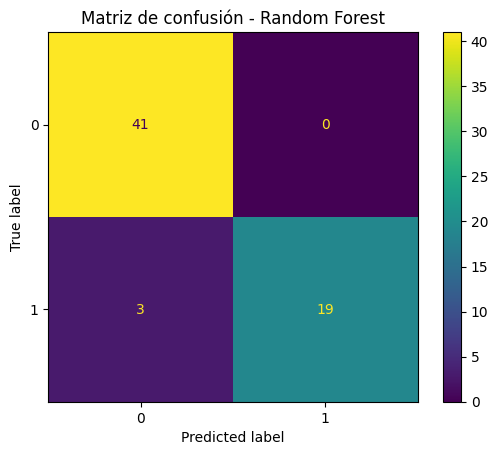

In [3]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print(classification_report(y_test, pred_rf, digits=3))

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Matriz de confusión - Random Forest")
plt.show()

## Curva ROC

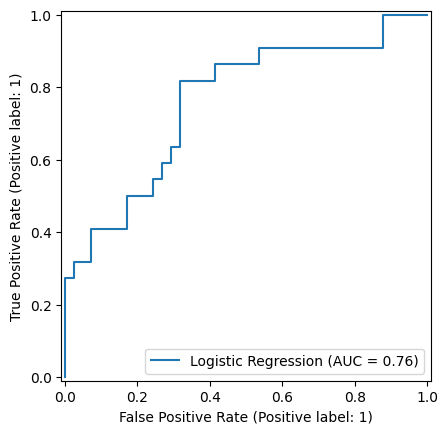

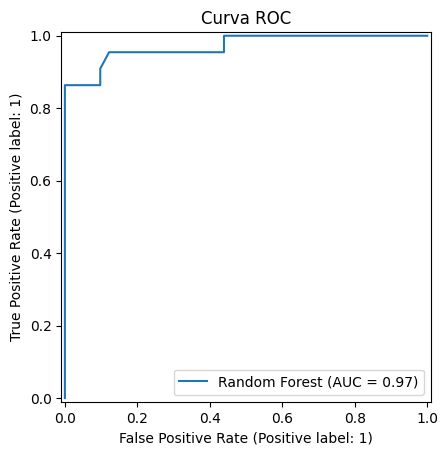

In [4]:
RocCurveDisplay.from_estimator(logit, X_test, y_test, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
plt.title("Curva ROC")
plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.


=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0      0.739     0.829     0.782        41
           1      0.588     0.455     0.513        22

    accuracy                          0.698        63
   macro avg      0.664     0.642     0.647        63
weighted avg      0.686     0.698     0.688        63


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0      0.927     0.927     0.927        41
           1      0.864     0.864     0.864        22

    accuracy                          0.905        63
   macro avg      0.895     0.895     0.895        63
weighted avg      0.905     0.905     0.905        63



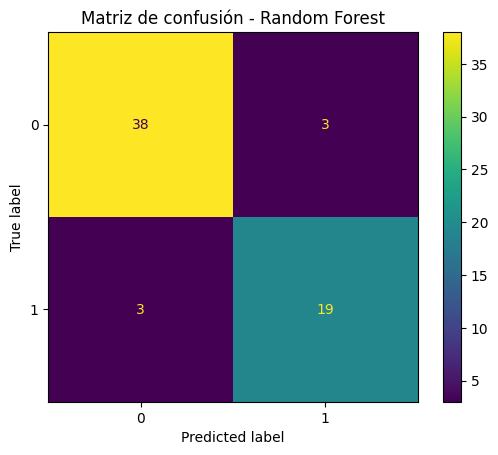

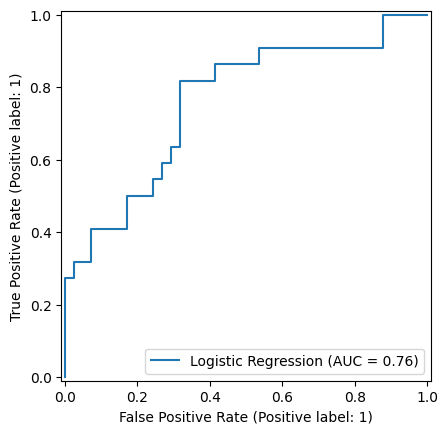

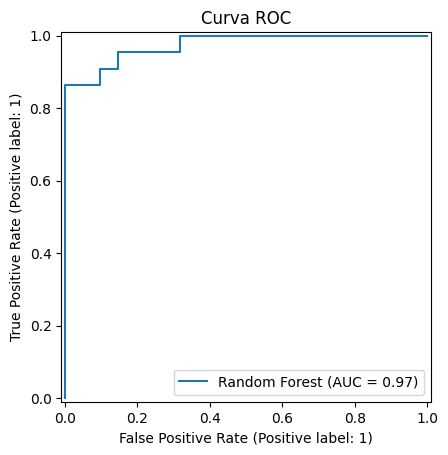


=== RANDOM FOREST (UMBRAL AJUSTADO) ===
Threshold usado: 0.35
              precision    recall  f1-score   support

           0      0.947     0.878     0.911        41
           1      0.800     0.909     0.851        22

    accuracy                          0.889        63
   macro avg      0.874     0.894     0.881        63
weighted avg      0.896     0.889     0.890        63



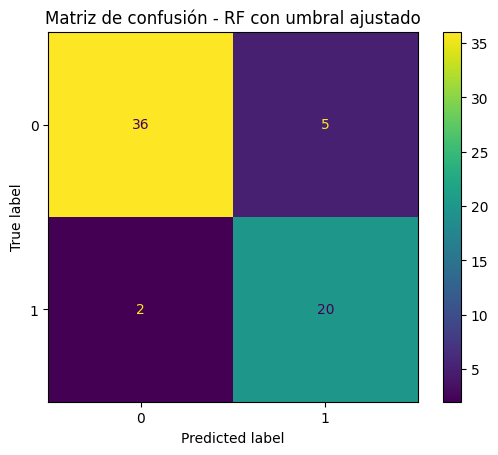


INTERPRETACIÓN:

El Random Forest funciona mejor en general que la regresión logística, sobre todo en recall, 
que en este caso es lo más importante porque queremos detectar el mayor número posible de clientes que se van.

Al bajar el umbral a 0.35, el modelo se vuelve más sensible y detecta más casos de abandono. 
Esto mejora el recall, pero también hace que aumenten los falsos positivos.

En un contexto de empresa, este ajuste tiene sentido si es más grave no detectar a un cliente que se va que marcar 
como abandono a alguien que en realidad no lo es.



In [8]:
# -----------------------------
# AÑADIR LIBRERIAS FALTANTES QUE VAYAMOS A UTILIZAR
# -----------------------------

from sklearn.metrics import confusion_matrix


# -----------------------------
# MODIFICACIÓN DEL DATASET
# -----------------------------
# Creamos una nueva variable como ejemplo de mejora del dataset
# Esto ayuda a que el modelo capture relaciones no lineales

if "antiguedad" in df.columns:
    df["antiguedad_squared"] = df["antiguedad"] ** 2

# Separación X / y
X = df.drop(columns=["abandono"])
y = df["abandono"]

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# -----------------------------
# MODELO 1: REGRESIÓN LOGÍSTICA
# -----------------------------
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logit.fit(X_train, y_train)
pred_logit = logit.predict(X_test)

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, pred_logit, digits=3))

# -----------------------------
# MODELO 2: RANDOM FOREST (HIPERPARÁMETROS MODIFICADOS)
# -----------------------------
# Cambios realizados:
# - más árboles
# - mayor profundidad
# - balance de clases reforzado
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, pred_rf, digits=3))

# -----------------------------
# MATRIZ DE CONFUSIÓN
# -----------------------------
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Matriz de confusión - Random Forest")
plt.show()

# -----------------------------
# CURVA ROC
# -----------------------------
RocCurveDisplay.from_estimator(logit, X_test, y_test, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
plt.title("Curva ROC")
plt.show()

# -----------------------------
# AJUSTE DE UMBRAL
# -----------------------------
# Queremos detectar MÁS abandonos → priorizamos RECALL
proba_rf = rf.predict_proba(X_test)[:, 1]

# bajamos el umbral de 0.5 a 0.35 para detectar más positivos
threshold = 0.35
pred_rf_threshold = (proba_rf >= threshold).astype(int)

print("\n=== RANDOM FOREST (UMBRAL AJUSTADO) ===")
print(f"Threshold usado: {threshold}")
print(classification_report(y_test, pred_rf_threshold, digits=3))

# Matriz de confusión con nuevo umbral
cm = confusion_matrix(y_test, pred_rf_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - RF con umbral ajustado")
plt.show()

# -----------------------------
# INTERPRETACIÓN FINAL
# -----------------------------
print("""
INTERPRETACIÓN:

El Random Forest funciona mejor en general que la regresión logística, sobre todo en recall, 
que en este caso es lo más importante porque queremos detectar el mayor número posible de clientes que se van.

Al bajar el umbral a 0.35, el modelo se vuelve más sensible y detecta más casos de abandono. 
Esto mejora el recall, pero también hace que aumenten los falsos positivos.

En un contexto de empresa, este ajuste tiene sentido si es más grave no detectar a un cliente que se va que marcar 
como abandono a alguien que en realidad no lo es.
""")
